# ECE1508 Tutorial:
## Score-Based Diffusion Models:

1. A score function gives a direction for sampling.
2. Langevin dynamics turns a score into samples.
3. A forward diffusion turns data into noise.
4. A reverse diffusion needs time-dependent scores.
5. Denoising score matching gives a practical training target for those scores.


## 1. Setup

We will use a 2D mixture of Gaussians as a tiny data distribution. It is simple enough that we can compute the true score analytically, which gives us a clean reference before training a neural score model.


In [1]:
import math
import time

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

plt.rcParams.update({
    "figure.figsize": (6, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})


Using device: cpu


In [2]:
def make_ring_means(k=8, radius=1.35, device=device):
    angles = torch.linspace(0, 2 * math.pi, k + 1, device=device)[:-1]
    return radius * torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)

MEANS = make_ring_means()
DATA_SIGMA = 0.07

@torch.no_grad()
def sample_data(n, means=MEANS, data_sigma=DATA_SIGMA):
    idx = torch.randint(0, means.shape[0], (n,), device=means.device)
    x = means[idx] + data_sigma * torch.randn(n, 2, device=means.device)
    return x, idx

def mixture_log_prob_and_score(x, sigma, means=MEANS):
    """Log density and score for an equally weighted isotropic Gaussian mixture."""
    if not torch.is_tensor(sigma):
        sigma = torch.tensor(float(sigma), device=x.device, dtype=x.dtype)
    sigma = sigma.to(device=x.device, dtype=x.dtype)

    diff = x[:, None, :] - means[None, :, :].to(x.device, x.dtype)
    if sigma.ndim == 0:
        var = sigma.square()
        log_comp = -0.5 * diff.square().sum(dim=-1) / var
        log_comp = log_comp - x.shape[-1] * torch.log(sigma) - math.log(2 * math.pi) - math.log(means.shape[0])
        resp = torch.softmax(log_comp, dim=1)
        score = -(resp[:, :, None] * diff / var).sum(dim=1)
    else:
        sigma = sigma.view(-1, 1, 1)
        var = sigma.square()
        log_comp = -0.5 * diff.square().sum(dim=-1) / var.squeeze(-1)
        log_comp = log_comp - x.shape[-1] * torch.log(sigma.squeeze(-1)) - math.log(2 * math.pi) - math.log(means.shape[0])
        resp = torch.softmax(log_comp, dim=1)
        score = -(resp[:, :, None] * diff / var).sum(dim=1)

    log_prob = torch.logsumexp(log_comp, dim=1)
    return log_prob, score

def data_score(x):
    return mixture_log_prob_and_score(x, DATA_SIGMA)[1]

def noisy_mixture_score(z, noise_sigma):
    total_sigma = torch.sqrt(torch.as_tensor(noise_sigma, device=z.device, dtype=z.dtype).square() + DATA_SIGMA ** 2)
    return mixture_log_prob_and_score(z, total_sigma)[1]


In [3]:
def score_grid(score_fn, lim=2.2, grid=25):
    xs = torch.linspace(-lim, lim, grid, device=device)
    yy, xx = torch.meshgrid(xs, xs, indexing="ij")
    pts = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)
    with torch.no_grad():
        score = score_fn(pts).detach().cpu().numpy()
    X = pts[:, 0].detach().cpu().numpy().reshape(grid, grid)
    Y = pts[:, 1].detach().cpu().numpy().reshape(grid, grid)
    U = score[:, 0].reshape(grid, grid)
    V = score[:, 1].reshape(grid, grid)
    speed = np.sqrt(U ** 2 + V ** 2) + 1e-8
    return X, Y, U / speed, V / speed, speed

def draw_score_field(ax, score_fn, title, lim=2.2, grid=25):
    X, Y, U, V, speed = score_grid(score_fn, lim=lim, grid=grid)
    q = ax.quiver(X, Y, U, V, speed, cmap="viridis", scale=18, width=0.004)
    ax.set_title(title)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    return q

def scatter_samples(ax, x, title=None, s=5, alpha=0.45, color="black"):
    x = x.detach().cpu().numpy()
    ax.scatter(x[:, 0], x[:, 1], s=s, alpha=alpha, color=color, linewidths=0)
    if title is not None:
        ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)


## 2. Score Functions and Langevin Dynamics

Lectures introduce the score function

$$
s(x) = \nabla_x \log p(x).
$$

The key observation is that we can sample using the score without evaluating the normalized probability density. The Langevin update used in the slides is the Euler approximation of the Langevin equation:

$$
x_{k+1} = x_k + \epsilon\, \nabla_x \log p(x_k) + \sqrt{2\epsilon}\,\xi_k, \qquad \xi_k \sim \mathcal{N}(0, I).
$$

The score pulls points toward high-density regions; the Gaussian noise keeps the chain exploring instead of collapsing immediately to a mode.


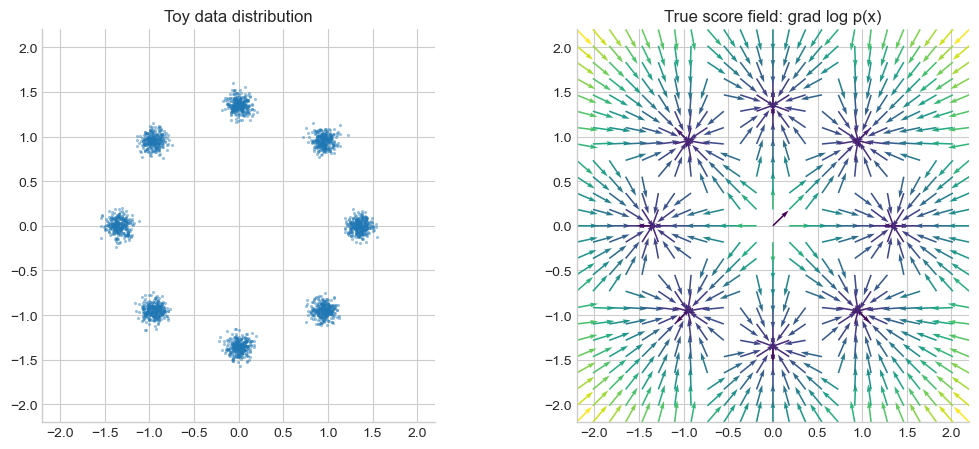

In [4]:
x_data, _ = sample_data(2500)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
scatter_samples(axes[0], x_data, "Toy data distribution", color="tab:blue")
draw_score_field(axes[1], data_score, "True score field: grad log p(x)")
plt.tight_layout()
plt.show()


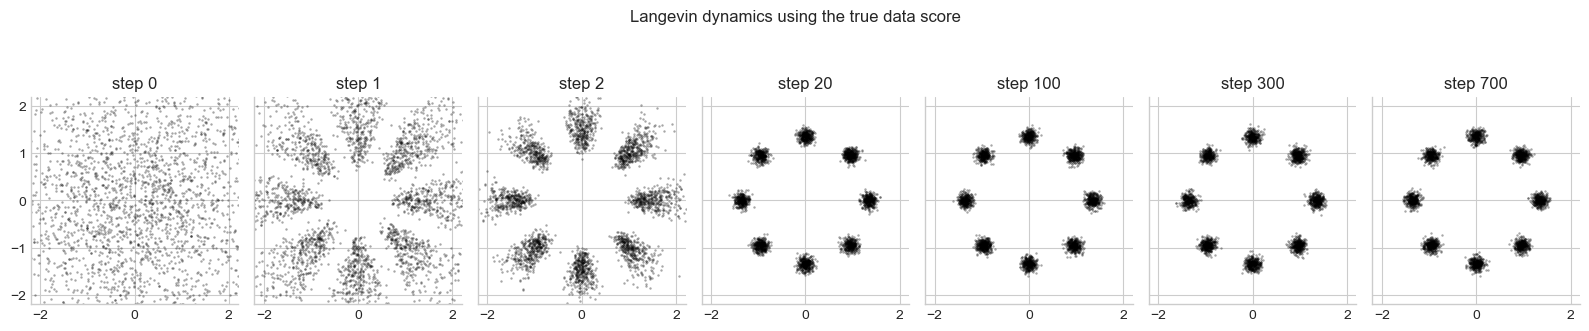

In [7]:
@torch.no_grad()
def langevin_sample(score_fn, n=3000, steps=700, step_size=0.0025, init_std=1.7, capture=(0, 1, 2, 20, 100, 300, 700)):
    x = init_std * torch.randn(n, 2, device=device)
    snapshots = {0: x.detach().cpu()}
    capture = set(capture)
    for step in range(1, steps + 1):
        noise = torch.randn_like(x)
        x = x + step_size * score_fn(x) + math.sqrt(2 * step_size) * noise
        if step in capture:
            snapshots[step] = x.detach().cpu()
    return x.detach().cpu(), snapshots

samples_langevin, snapshots = langevin_sample(data_score)

fig, axes = plt.subplots(1, len(snapshots), figsize=(16, 3.2), sharex=True, sharey=True)
for ax, (step, x_step) in zip(axes, snapshots.items()):
    scatter_samples(ax, x_step, f"step {step}", s=3, alpha=0.35)
plt.suptitle("Langevin dynamics using the true data score", y=1.05)
plt.tight_layout()
plt.show()


## 3. Score Matching in One Slide

If the score is enough for sampling, can we learn the score directly?

A score model is a vector-valued function

$$
s_\theta(x) \approx \nabla_x \log p_{data}(x).
$$

The direct objective would be

$$
R(\theta) = \mathbb{E}_{x \sim p_{data}} \left[\|s_\theta(x) - \nabla_x \log p_{data}(x)\|^2\right].
$$

The problem is that the true data score is unknown. Hyvarinen score matching rewrites this, up to constants and convention-dependent factors, as an objective that uses only samples:

$$
\mathbb{E}_{p_{data}}\left[\|s_\theta(x)\|^2 + 2\,\mathrm{div}\,s_\theta(x)\right].
$$

This is elegant, but the divergence/Jacobian term is expensive for high-dimensional neural networks. Section 2's denoising score matching is the practical way out.


## 4. Forward Diffusion: Data to Noise

Let's generalize Langevin dynamics to an SDE

$$
dx(t) = f(x(t), t)\,dt + g(t)\,dB(t).
$$

A common noising chain is an Ornstein-Uhlenbeck style update:

$$
x_{i+1} = \mu_i x_i + \sqrt{1 - \mu_i^2}\,\epsilon_i,
\qquad \epsilon_i \sim \mathcal{N}(0, I).
$$

For centered, normalized data, repeated application pushes the distribution toward a standard Gaussian. The reverse process is the generative direction: start from noise and move back toward data.


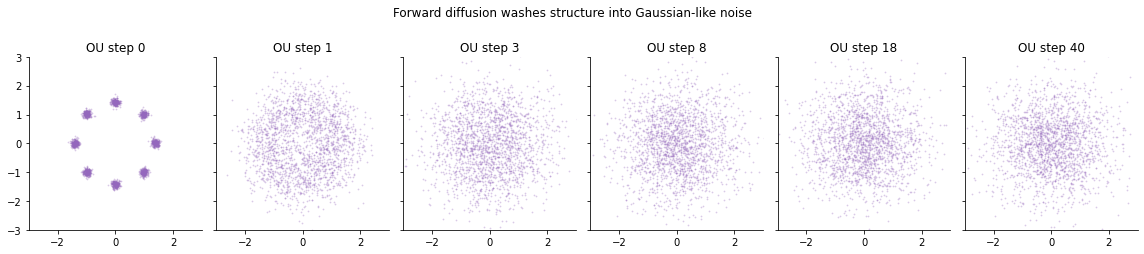

In [6]:
@torch.no_grad()
def ou_forward_snapshots(x0, mu=0.86, steps=(0, 1, 3, 8, 18, 40)):
    x = x0.clone()
    snapshots = {0: x.detach().cpu()}
    max_step = max(steps)
    for step in range(1, max_step + 1):
        x = mu * x + math.sqrt(1 - mu ** 2) * torch.randn_like(x)
        if step in steps:
            snapshots[step] = x.detach().cpu()
    return snapshots

x0, _ = sample_data(2000)
# Roughly center and normalize for the OU demonstration.
x0_norm = (x0 - x0.mean(dim=0, keepdim=True)) / x0.std(dim=0, keepdim=True)
snaps = ou_forward_snapshots(x0_norm)

fig, axes = plt.subplots(1, len(snaps), figsize=(16, 3.1), sharex=True, sharey=True)
for ax, (step, x_step) in zip(axes, snaps.items()):
    scatter_samples(ax, x_step, f"OU step {step}", s=3, alpha=0.35, color="tab:purple")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
plt.suptitle("Forward diffusion washes structure into Gaussian-like noise", y=1.06)
plt.tight_layout()
plt.show()


## 5. Reverse Diffusion Needs Scores at Every Noise Level

The reverse-time SDE result says that if we know the forward process and the score of each noisy marginal, then we can reverse the diffusion statistically. The exact signs depend on the time convention, but the important dependency is the same:

$$
\text{reverse drift} = \text{known forward terms} + \text{a term involving } \nabla_x \log p_t(x).
$$

So the learning problem becomes time dependent:

$$
s_\theta(x, t) \approx \nabla_x \log p_t(x).
$$

Let's use the equivalent noisy-sample view:

$$
z = x + \sigma \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I).
$$

The noisy marginal score satisfies

$$
\nabla_z \log p_\sigma(z)
= \mathbb{E}\left[\frac{x-z}{\sigma^2}\mid z\right]
= -\frac{1}{\sigma}\mathbb{E}[\epsilon \mid z].
$$

This identity connects denoising and score estimation.


## 6. Train a Denoising Score Model

Denoising score matching trains on samples we can generate ourselves:

1. Draw clean data `x`.
2. Draw a noise level `sigma`.
3. Form `z = x + sigma * epsilon`.
4. Train `s_theta(z, sigma)` toward `(x - z) / sigma^2 = -epsilon / sigma`.

At optimum, the model learns the marginal noisy score, not merely the score of the conditional corruption kernel.


In [8]:
SIGMAS = torch.exp(torch.linspace(math.log(0.05), math.log(1.25), 12, device=device))

class ScoreNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, z, sigma):
        log_sigma = sigma.log().view(-1, 1)
        features = torch.cat([z, log_sigma, torch.sin(log_sigma), torch.cos(log_sigma)], dim=1)
        return self.net(features)

def make_dsm_batch(batch_size):
    x, _ = sample_data(batch_size)
    idx = torch.randint(0, SIGMAS.numel(), (batch_size,), device=device)
    sigma = SIGMAS[idx]
    eps = torch.randn_like(x)
    z = x + sigma[:, None] * eps
    target = -eps / sigma[:, None]
    return z, sigma, target

score_model = ScoreNet().to(device)
optimizer = torch.optim.AdamW(score_model.parameters(), lr=2e-3, weight_decay=1e-4)

TRAIN_STEPS = 900
BATCH_SIZE = 768
losses = []
start = time.time()

for step in range(1, TRAIN_STEPS + 1):
    z, sigma, target = make_dsm_batch(BATCH_SIZE)
    pred = score_model(z, sigma)
    per_sample = (pred - target).square().sum(dim=1)
    loss = (sigma.square() * per_sample).mean()

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if step == 1 or step % 150 == 0:
        print(f"step {step:4d} | weighted DSM loss {loss.item():.4f}")

print(f"Training time: {time.time() - start:.1f} seconds")


step    1 | weighted DSM loss 2.1259
step  150 | weighted DSM loss 1.5415
step  300 | weighted DSM loss 1.3833
step  450 | weighted DSM loss 1.1900
step  600 | weighted DSM loss 0.9617
step  750 | weighted DSM loss 0.9229
step  900 | weighted DSM loss 0.9590
Training time: 5.1 seconds


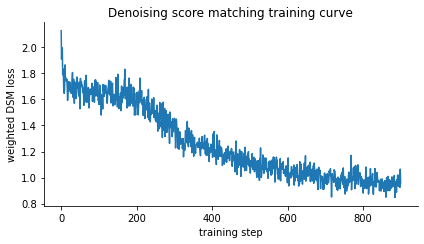

In [9]:
plt.figure(figsize=(6, 3.5))
plt.plot(losses)
plt.xlabel("training step")
plt.ylabel("weighted DSM loss")
plt.title("Denoising score matching training curve")
plt.tight_layout()
plt.show()


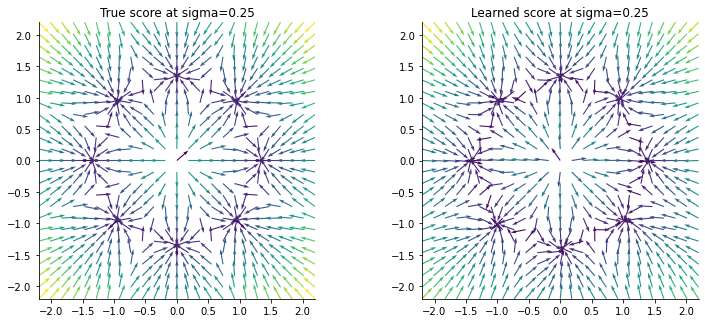

In [10]:
@torch.no_grad()
def model_score_fn(model, sigma_value):
    def fn(x):
        sigma = torch.full((x.shape[0],), float(sigma_value), device=x.device, dtype=x.dtype)
        return model(x, sigma)
    return fn

sigma_to_check = 0.25
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
draw_score_field(axes[0], lambda pts: noisy_mixture_score(pts, sigma_to_check), f"True score at sigma={sigma_to_check}")
draw_score_field(axes[1], model_score_fn(score_model, sigma_to_check), f"Learned score at sigma={sigma_to_check}")
plt.tight_layout()
plt.show()


## 7. Sample with the Learned Score

To keep the tutorial compact, we use annealed Langevin sampling rather than implementing a full solver for the reverse SDE. The idea is still:

1. Start at a high-noise distribution.
2. Move from large `sigma` to small `sigma`.
3. At each noise level, run Langevin dynamics using `s_theta(x, sigma)`.

This approximates sampling from progressively less noisy marginals until the samples look like data.


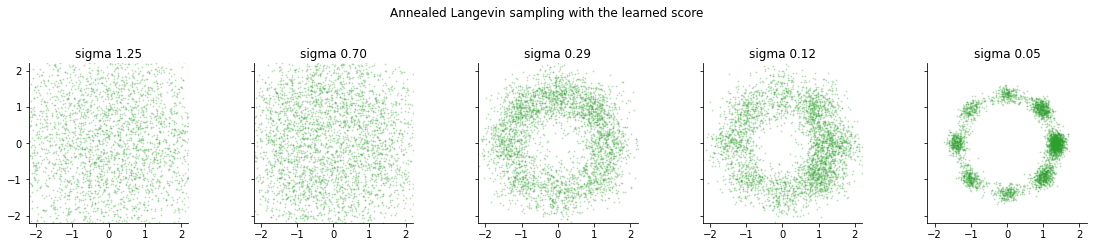

In [11]:
@torch.no_grad()
def annealed_langevin(model, n=3500, steps_each=35, base_step=0.006):
    descending_sigmas = torch.flip(SIGMAS, dims=[0])
    x = torch.randn(n, 2, device=device) * descending_sigmas[0]
    snapshots = {}
    min_sigma = SIGMAS.min()

    for level, sigma in enumerate(descending_sigmas):
        step_size = base_step * (sigma / min_sigma).square().item()
        step_size = min(step_size, 0.045)
        sigma_batch = torch.full((n,), float(sigma), device=device)
        for _ in range(steps_each):
            score = model(x, sigma_batch)
            x = x + step_size * score + math.sqrt(2 * step_size) * torch.randn_like(x)
        if level in {0, 2, 5, 8, len(descending_sigmas) - 1}:
            snapshots[float(sigma)] = x.detach().cpu()
    return x.detach().cpu(), snapshots

samples, sample_snaps = annealed_langevin(score_model)

fig, axes = plt.subplots(1, len(sample_snaps), figsize=(16, 3.1), sharex=True, sharey=True)
for ax, (sigma, x_step) in zip(axes, sample_snaps.items()):
    scatter_samples(ax, x_step, f"sigma {sigma:.2f}", s=3, alpha=0.35, color="tab:green")
plt.suptitle("Annealed Langevin sampling with the learned score", y=1.06)
plt.tight_layout()
plt.show()
